# Resumo do código

Enunciado do exercício: [exercicio_2.pdf](./exercicio_2.pdf).  

Este notebook resolve o exercício sobre **maior subsequência comum** (*Longest Common Subsequence*, LCS) entre as cadeias:

- `genoma = "ACCUGTATAUCGUCACTU"`
- `feature = "GCAUTTC"`

A solução usa **programação dinâmica**, conforme a abordagem matricial apresentada no material teórico. A matriz $L$ armazena, em cada posição $L[i][j]$, o tamanho da maior subsequência comum entre os prefixos `genoma[:i]` e `feature[:j]`. Depois de preencher a matriz, o código percorre essa tabela de trás para frente para reconstruir uma subsequência ótima.

## Organização das células

1. **Resumo do código**: apresenta o objetivo, as entradas e a estrutura do notebook.
2. **Ideia do algoritmo**: descreve a recorrência de programação dinâmica e o fluxo de reconstrução.
3. **Imports e configuração do ambiente**: carrega bibliotecas e configura diretórios locais do projeto.
4. **Entradas do exercício**: define `genoma` e `feature` e valida os caracteres.
5. **Construção da matriz LCS**: implementa o preenchimento da tabela de programação dinâmica.
6. **Reconstrução da subsequência**: implementa o retorno de uma subsequência comum máxima.
7. **Visualização da matriz**: transforma a tabela em `DataFrame` para leitura didática.
8. **Execução da solução**: calcula a resposta do exercício e exibe o resultado.
9. **Conferência da resposta**: valida se a saída é subsequência das duas cadeias.
10. **Estatísticas e complexidade**: mede tempo, memória e apresenta as ordens assintóticas.


## Ideia do algoritmo

Para duas cadeias $A$ e $B$, com tamanhos $n$ e $m$, a matriz $L$ é preenchida pela recorrência:

$$
L[i][j] =
\begin{cases}
0, & \text{se } i = 0 \text{ ou } j = 0 \\
L[i-1][j-1] + 1, & \text{se } A[i-1] = B[j-1] \\
\max(L[i-1][j], L[i][j-1]), & \text{caso contrário}
\end{cases}
$$

O valor $L[n][m]$ é o comprimento da maior subsequência comum. Para reconstruir a subsequência, partimos de $L[n][m]$ e voltamos pela matriz até chegar à primeira linha ou à primeira coluna.

```mermaid
flowchart TD
    A[Definir genoma e feature] --> B[Criar matriz L com zeros]
    B --> C{Caracteres atuais são iguais?}
    C -- Sim --> D[Usar diagonal + 1]
    C -- Não --> E[Usar máximo entre cima e esquerda]
    D --> F[Preencher próxima posição]
    E --> F
    F --> G{Matriz completa?}
    G -- Não --> C
    G -- Sim --> H[Voltar pela matriz]
    H --> I[Reconstruir uma LCS]
    I --> J[Exibir resultado e estatísticas]
```


In [1]:
# Esta célula importa as bibliotecas usadas e mantém os arquivos temporários dentro da pasta do projeto.
from __future__ import annotations

import os
import platform
import time
import tracemalloc
from dataclasses import dataclass
from pathlib import Path

PROJECT_DIR = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(PROJECT_DIR / ".cache"))
os.environ.setdefault("IPYTHONDIR", str(PROJECT_DIR / ".ipython"))
os.environ.setdefault("JUPYTER_RUNTIME_DIR", str(PROJECT_DIR / ".jupyter_runtime"))

for directory in [".matplotlib", ".cache", ".ipython", ".jupyter_runtime"]:
    (PROJECT_DIR / directory).mkdir(exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import psutil

print(f"Python em uso: {platform.python_version()}")
print(f"Diretório do projeto: {PROJECT_DIR}")


Python em uso: 3.14.0
Diretório do projeto: /Users/daltonreis/GitHub/disciplinas/UDESC_DR/2026/AlunoEspecial_2026-1_ProjetoAnaliseAlgoritmos/_Topico4/PAA_11_Exercicio_2


In [2]:
# Esta célula define as entradas do exercício e verifica se elas contêm somente caracteres esperados.
genoma = "ACCUGTATAUCGUCACTU"
feature = "GCAUTTC"
ALFABETO_RNA = set("ACGUT")


def validar_cadeia(nome: str, cadeia: str, alfabeto: set[str]) -> None:
    """Valida se uma cadeia não é vazia e se todos os seus caracteres pertencem ao alfabeto informado."""
    if not cadeia:
        raise ValueError(f"A cadeia '{nome}' não pode ser vazia.")
    caracteres_invalidos = sorted(set(cadeia) - alfabeto)
    if caracteres_invalidos:
        raise ValueError(
            f"A cadeia '{nome}' contém caracteres inválidos: {caracteres_invalidos}."
        )


validar_cadeia("genoma", genoma, ALFABETO_RNA)
validar_cadeia("feature", feature, ALFABETO_RNA)

print(f"Genoma:  {genoma} ({len(genoma)} caracteres)")
print(f"Feature: {feature} ({len(feature)} caracteres)")


Genoma:  ACCUGTATAUCGUCACTU (18 caracteres)
Feature: GCAUTTC (7 caracteres)


In [3]:
# Esta célula implementa a matriz de programação dinâmica para calcular o comprimento da LCS.
def construir_matriz_lcs(a: str, b: str) -> list[list[int]]:
    """Constrói a matriz LCS para as cadeias `a` e `b`.

    A posição matriz[i][j] guarda o comprimento da maior subsequência comum
    entre os prefixos a[:i] e b[:j].
    """
    linhas = len(a) + 1
    colunas = len(b) + 1
    matriz = [[0] * colunas for _ in range(linhas)]

    for i in range(1, linhas):
        for j in range(1, colunas):
            if a[i - 1] == b[j - 1]:
                matriz[i][j] = matriz[i - 1][j - 1] + 1
            else:
                matriz[i][j] = max(matriz[i - 1][j], matriz[i][j - 1])

    return matriz


In [4]:
# Esta célula reconstrói uma maior subsequência comum a partir da matriz já preenchida.
def reconstruir_lcs(a: str, b: str, matriz: list[list[int]]) -> str:
    """Reconstrói uma LCS usando a matriz calculada por `construir_matriz_lcs`.

    Em caso de empate entre mover para cima ou para a esquerda, o código move
    para cima. Essa regra torna o resultado determinístico quando há mais de
    uma subsequência ótima possível.
    """
    i = len(a)
    j = len(b)
    caracteres: list[str] = []

    while i > 0 and j > 0:
        if a[i - 1] == b[j - 1]:
            caracteres.append(a[i - 1])
            i -= 1
            j -= 1
        elif matriz[i - 1][j] >= matriz[i][j - 1]:
            i -= 1
        else:
            j -= 1

    return "".join(reversed(caracteres))


In [5]:
# Esta célula formata a matriz LCS como tabela, com rótulos que facilitam a leitura didática.
def matriz_lcs_com_rotulos(a: str, b: str, matriz: list[list[int]]) -> pd.DataFrame:
    """Retorna a matriz LCS em um DataFrame com rótulos de linhas e colunas."""
    rotulos_linhas = ["∅"] + list(a)
    rotulos_colunas = ["∅"] + list(b)
    return pd.DataFrame(matriz, index=rotulos_linhas, columns=rotulos_colunas)


matriz = construir_matriz_lcs(genoma, feature)
tabela_lcs = matriz_lcs_com_rotulos(genoma, feature, matriz)
tabela_lcs


,∅,G,C,A,U,T,T,C
∅,0,0,0,0,0,0,0,0
A,0,0,0,1,1,1,1,1
C,0,0,1,1,1,1,1,2
C,0,0,1,1,1,1,1,2
U,0,0,1,1,2,2,2,2
G,0,1,1,1,2,2,2,2
T,0,1,1,1,2,3,3,3
A,0,1,1,2,2,3,3,3
T,0,1,1,2,2,3,4,4
A,0,1,1,2,2,3,4,4


Resultado do exercício
Maior subsequência comum encontrada: AUTTC
Comprimento da maior subsequência comum: 5


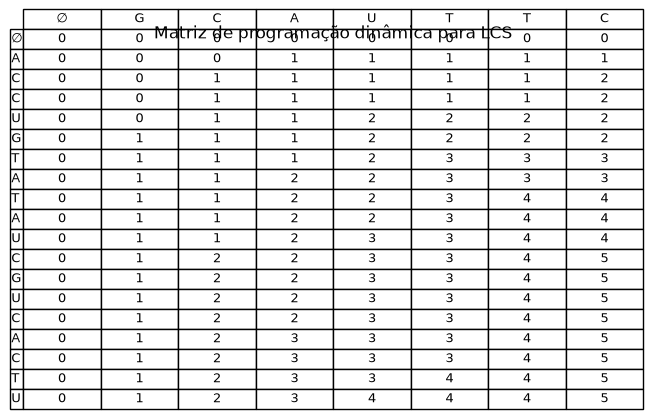

In [6]:
# Esta célula executa a solução completa para o enunciado e apresenta a maior subsequência comum encontrada.
subsequencia = reconstruir_lcs(genoma, feature, matriz)
comprimento = matriz[len(genoma)][len(feature)]

print("Resultado do exercício")
print(f"Maior subsequência comum encontrada: {subsequencia}")
print(f"Comprimento da maior subsequência comum: {comprimento}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
tabela_visual = ax.table(
    cellText=tabela_lcs.values,
    rowLabels=tabela_lcs.index,
    colLabels=tabela_lcs.columns,
    loc="center",
    cellLoc="center",
)
tabela_visual.auto_set_font_size(False)
tabela_visual.set_fontsize(9)
tabela_visual.scale(1.0, 1.2)
ax.set_title("Matriz de programação dinâmica para LCS", pad=12)
plt.show()


In [7]:
# Esta célula confere se a resposta reconstruída é, de fato, subsequência das duas cadeias de entrada.
def eh_subsequencia(candidata: str, cadeia: str) -> bool:
    """Verifica se `candidata` aparece em `cadeia` mantendo a ordem dos caracteres."""
    iterador = iter(cadeia)
    return all(caractere in iterador for caractere in candidata)


assert len(subsequencia) == comprimento, "O tamanho reconstruído não coincide com a matriz LCS."
assert eh_subsequencia(subsequencia, genoma), "A resposta não é subsequência do genoma."
assert eh_subsequencia(subsequencia, feature), "A resposta não é subsequência da feature."

print("Conferência concluída com sucesso.")
print(f"'{subsequencia}' é subsequência de '{genoma}' e de '{feature}'.")


Conferência concluída com sucesso.
'AUTTC' é subsequência de 'ACCUGTATAUCGUCACTU' e de 'GCAUTTC'.


In [8]:
# Esta célula mede tempo e memória da solução e resume as complexidades assintóticas do algoritmo.
@dataclass(frozen=True)
class EstatisticasExecucao:
    tempo_ms: float
    memoria_atual_kib: float
    pico_memoria_kib: float
    memoria_processo_mib: float
    n: int
    m: int
    celulas_matriz: int


def medir_lcs(a: str, b: str) -> tuple[str, EstatisticasExecucao]:
    """Executa a LCS medindo tempo e alocação de memória rastreada."""
    processo = psutil.Process(os.getpid())
    tracemalloc.start()
    inicio = time.perf_counter()

    matriz_medida = construir_matriz_lcs(a, b)
    resposta = reconstruir_lcs(a, b, matriz_medida)

    fim = time.perf_counter()
    memoria_atual, pico_memoria = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    estatisticas = EstatisticasExecucao(
        tempo_ms=(fim - inicio) * 1000,
        memoria_atual_kib=memoria_atual / 1024,
        pico_memoria_kib=pico_memoria / 1024,
        memoria_processo_mib=processo.memory_info().rss / (1024 * 1024),
        n=len(a),
        m=len(b),
        celulas_matriz=(len(a) + 1) * (len(b) + 1),
    )
    return resposta, estatisticas


resposta_medida, estatisticas = medir_lcs(genoma, feature)

print("Estatísticas de execução")
print(f"Resposta medida: {resposta_medida}")
print(f"Tempo de processamento: {estatisticas.tempo_ms:.4f} ms")
print(f"Pico de memória rastreada: {estatisticas.pico_memoria_kib:.2f} KiB")
print(f"Memória residente do processo Python: {estatisticas.memoria_processo_mib:.2f} MiB")
print(f"Dimensões consideradas: n = {estatisticas.n}, m = {estatisticas.m}")
print(f"Células da matriz: {estatisticas.celulas_matriz}")
print("Complexidade de tempo: O(n · m), pois cada célula da matriz é preenchida uma vez.")
print("Complexidade de espaço: O(n · m), pois a matriz completa é mantida para reconstruir a LCS.")


Estatísticas de execução
Resposta medida: AUTTC
Tempo de processamento: 0.0416 ms
Pico de memória rastreada: 1.58 KiB
Memória residente do processo Python: 157.27 MiB
Dimensões consideradas: n = 18, m = 7
Células da matriz: 152
Complexidade de tempo: O(n · m), pois cada célula da matriz é preenchida uma vez.
Complexidade de espaço: O(n · m), pois a matriz completa é mantida para reconstruir a LCS.
